## 3DoF Entry VTOL w/o Aoa SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Trajopt imports
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.problem as prob
import trajopt.utils.config_loader as cfg

create problem and run SCP

In [2]:
# create problem instance
config  = cfg.load_configs("vtol1_entry_3dof")
problem = prob.Problem(config)

# run SCP
problem = scp.run_scp(problem)

scales: 
d: 6378137.0000, t: 806.3293, m: 104305.0000, v: 7910.0900, a: 9.8100, f: 1023232.0500, ang: 57.2958, angv: 0.0711
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: vtol: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:250: UserWarning: Your problem has too many parameters for efficient DPP compilation. We suggest setting 'ignore_dpp = True'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    02438.1   |   0006.7  |   10389.3   |   -2.8    |      -12.0      |    -02.2    |     -12.0   |    optimal    |   1824.13   |  435.8
     02     |    00016.4   |   0007.0  |   0001.5   |   -2.2    |      -12.0      |    -02.2    |     -12.0   |    optimal    |   1879.76   |  301.7
     03     |    00014.0   |   0010.4  |   0001.0   |   -2.6    |      -12.0      |    -02.4    |     -12.0   |    optimal    |   1723.12   |  579.4
     04     |    00014.5   |   0008.4  |   0001.2   |   -2.8    |      -12.0      |    -02.8    |     -12.0   |    optimal    |   1626.72   |  877.7
     05     |    00015.2   |   0009.5  |   0000.8   |   -2.9    |      -12.0      |    -02.9    |     -12.0   |    optimal    |   1653.59   |  713.3
     06     |    00020.7   |   0009.1  |   0001.6   |   -3.0    |      -12.0      |    -03.0    |     -12.0   |    optimal    |   1668.59   |  661.7
     07     |    00015.6   |   0007.6  |   0001.0   |   -3.6    |      -12.0      |    -03.1    |     -12

run SCP

make plots

final time: 1721.3291092019724


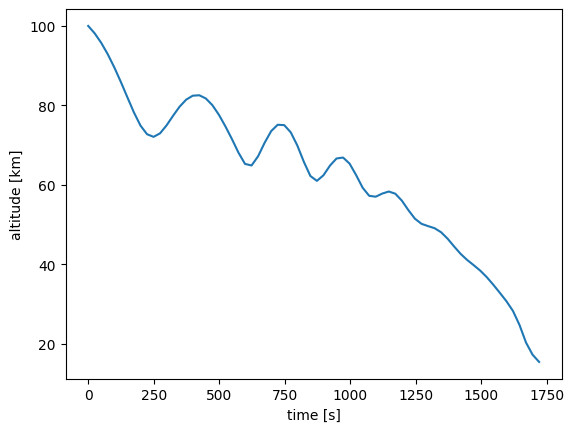

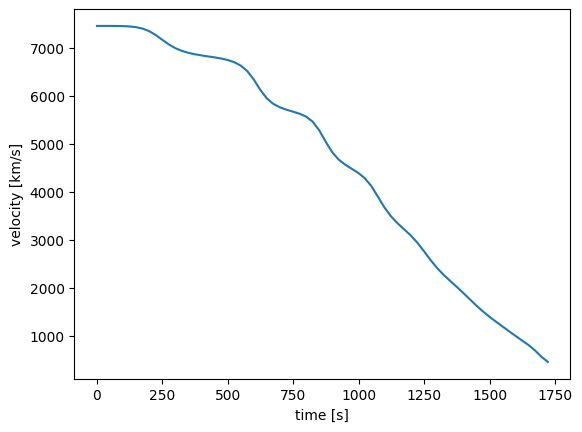

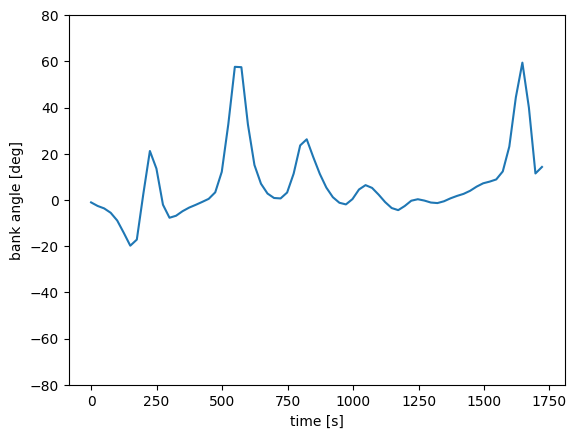

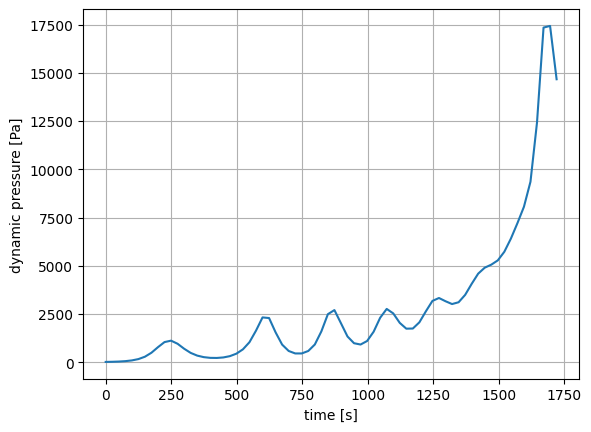

In [3]:
# --- 3D Interactivity (run %matplotlib widget in Jupyter) ---
#%matplotlib widget # ← run this once per notebook session

mission = problem.mission
model   = problem.model
method  = problem.method

# --- Retrieve trajectory and parameters ---

t_init = method.t_init
z_init = method.z_init
nu_init = method.nu_init
x_init  = z_init[:, 0]
y_init  = z_init[:, 1]
z_init  = z_init[:, 2]

t_opt  = problem.solution["ts"]
z_opt  = problem.solution["zs"]
nu_opt  = problem.solution["us"]

nd = method.nondim['nd']
nt = method.nondim['nt']
nm = method.nondim['nm']

plt.plot(t_opt * nt, (z_opt[:, 0] * nd - mission.planet['r']) / 1e3)
plt.ylabel('altitude [km]')
plt.xlabel('time [s]')

plt.figure()
plt.plot(t_opt*method.nondim['nt'], (z_opt[:, 3] * method.nondim['nv']))
plt.ylabel('velocity [km/s]')
plt.xlabel('time [s]')

plt.figure()
plt.plot(t_opt*method.nondim['nt'], np.rad2deg(nu_opt[:, 0]))
plt.ylabel('bank angle [deg]')
plt.ylim(-80, 80)
plt.xlabel('time [s]')

# Extract original state (first n columns) when CTCS is enabled
n = problem.model.n
z_state = problem.solution["zs"][:, :n]

# Get state variables
rs = z_state[:, 0]  # radius
vs = z_state[:, 3]  # velocity

# Compute density and dynamic pressure
rho = np.array([problem.mission.mission_module.atmosphere_model_jax(r, problem) for r in rs])
nv = method.nondim["nv"]
q_dyn = 0.5 * rho * (vs * nv) ** 2

# Plot
plt.figure()
plt.plot(t_opt * method.nondim['nt'], q_dyn)
plt.ylabel('dynamic pressure [Pa]')
plt.xlabel('time [s]')
plt.grid(True)

print(f"final time: {t_opt[-1] * method.nondim['nt']}")

/var/folders/n9/dn62rvtx7lv7nshhyvqwfckr0000gn/T/ipykernel_40943/4164756921.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((xc_deg[i], yc_deg[i]), rc_deg[i], color='red', fill=True, alpha=0.4,


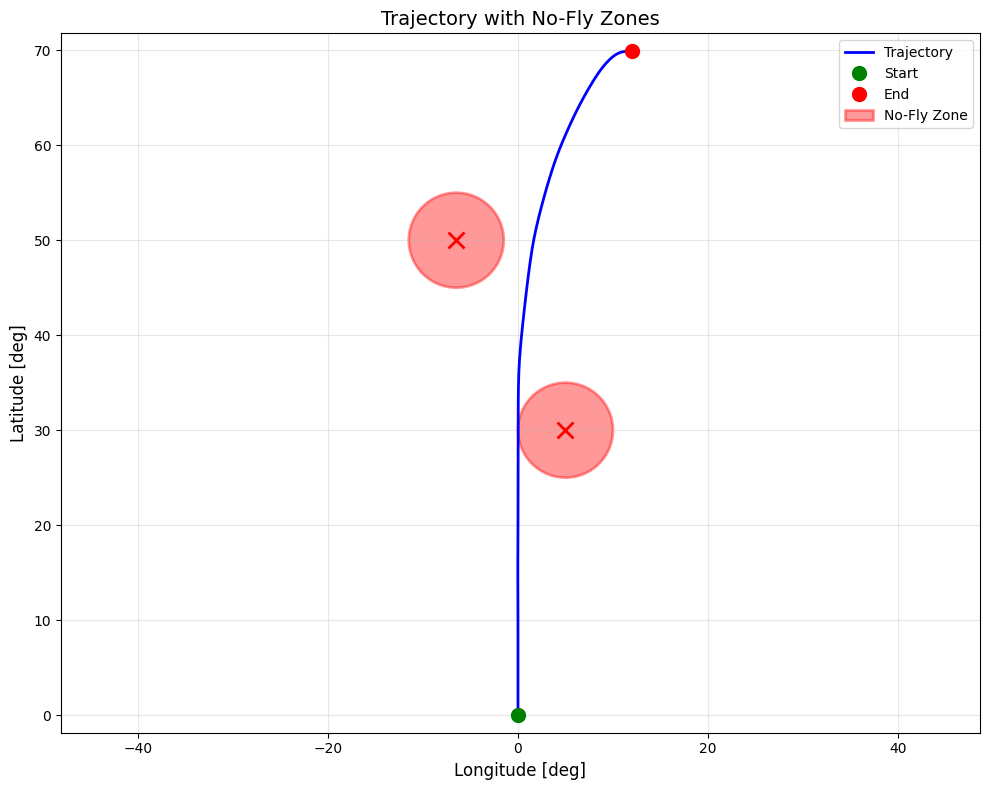

In [5]:
# Extract original state (first n columns) when CTCS is enabled
n = problem.model.n
z_state = problem.solution["zs"][:, :n]

# Get longitude (theta) and latitude (phi) from state
# State indices: x_idx=1 (longitude), y_idx=2 (latitude)
theta = z_state[:, 1]  # longitude
phi = z_state[:, 2]    # latitude

# Convert to degrees if needed (check if they're in radians)
import numpy as np
theta_deg = np.rad2deg(theta) if np.max(np.abs(theta)) < 10 else theta
phi_deg = np.rad2deg(phi) if np.max(np.abs(phi)) < 10 else phi

# Get NFZ parameters
xc_deg = np.array(problem.mission.obs["xc"])
yc_deg = np.array(problem.mission.obs["yc"])
rc_deg = np.array(problem.mission.obs["rc"])

# Plot trajectory
plt.figure(figsize=(10, 8))
plt.plot(theta_deg, phi_deg, 'b-', linewidth=2, label='Trajectory', zorder=2)
plt.plot(theta_deg[0], phi_deg[0], 'go', markersize=10, label='Start', zorder=3)
plt.plot(theta_deg[-1], phi_deg[-1], 'ro', markersize=10, label='End', zorder=3)

# Plot no-fly zones as circles
for i in range(len(xc_deg)):
    circle = plt.Circle((xc_deg[i], yc_deg[i]), rc_deg[i], color='red', fill=True, alpha=0.4, 
                       edgecolor='darkred', linewidth=2, label='No-Fly Zone' if i == 0 else '', zorder=1)
    plt.gca().add_patch(circle)
    # Also plot center point
    plt.plot(xc_deg[i], yc_deg[i], 'rx', markersize=12, markeredgewidth=2, zorder=4)

# Set axis limits to include both trajectory and NFZ circles
x_min = min(np.min(theta_deg), np.min(xc_deg - rc_deg)) - 2
x_max = max(np.max(theta_deg), np.max(xc_deg + rc_deg)) + 2
y_min = min(np.min(phi_deg), np.min(yc_deg - rc_deg)) - 2
y_max = max(np.max(phi_deg), np.max(yc_deg + rc_deg)) + 2

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xlabel('Longitude [deg]', fontsize=12)
plt.ylabel('Latitude [deg]', fontsize=12)
plt.title('Trajectory with No-Fly Zones', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()